# Data Preprocessing, Baseline MLP, and Experiments

This notebook covers the full workflow for the Steel Plates Faults dataset: preprocessing, baseline MLP training, and followup experiments:

- loading and cleaning the dataset
- removing target leakage columns, constant features, and perfectly redundant features
- separating features and target
- train/validation/test split with stratification
- checking split balance and missing values
- detecting binary and continuous variables
- transforming strongly skewed variables
- normalizing continuous features
- encoding target labels and validating the processed data
- training and evaluating a baseline MLP
- comparing several followup MLP experiments

The preprocessing decisions are based on the earlier EDA, and the modeling section uses the resulting processed splits to build a fair comparison between MLP variants.

In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Load the dataset

In [45]:
dataset_path = Path("../dataset/php9xWOpn.arff")

data, meta = arff.loadarff(dataset_path)
df = pd.DataFrame(data)


print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1941 non-null   float64
 1   V2      1941 non-null   float64
 2   V3      1941 non-null   float64
 3   V4      1941 non-null   float64
 4   V5      1941 non-null   float64
 5   V6      1941 non-null   float64
 6   V7      1941 non-null   float64
 7   V8      1941 non-null   float64
 8   V9      1941 non-null   float64
 9   V10     1941 non-null   float64
 10  V11     1941 non-null   float64
 11  V12     1941 non-null   float64
 12  V13     1941 non-null   float64
 13  V14     1941 non-null   float64
 14  V15     1941 non-null   float64
 15  V16     1941 non-null   float64
 16  V17     1941 non-null   float64
 17  V18     1941 non-null   float64
 18  V19     1941 non-null   float64
 19  V20     1941 non-null   float64
 20  V21     1941 non-null   float64
 21  V22     1941 non-null   float64
 22  V23     194

Convert `Class` column from object to string

In [46]:
df["Class"] = df["Class"].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x).astype("string")
print(df["Class"].dtype)

string


## Description of the dataframe

In [47]:
print(df.head())
print(df.shape)
print(df.columns.tolist())
print(df["Class"].value_counts())

       V1      V2         V3         V4      V5    V6     V7        V8    V9  \
0    42.0    50.0   270900.0   270944.0   267.0  17.0   44.0   24220.0  76.0   
1   645.0   651.0  2538079.0  2538108.0   108.0  10.0   30.0   11397.0  84.0   
2   829.0   835.0  1553913.0  1553931.0    71.0   8.0   19.0    7972.0  99.0   
3   853.0   860.0   369370.0   369415.0   176.0  13.0   45.0   18996.0  99.0   
4  1289.0  1306.0   498078.0   498335.0  2409.0  60.0  260.0  246930.0  37.0   

     V10  ...     V25     V26     V27  V28  V29  V30  V31  V32  V33  Class  
0  108.0  ...  0.8182 -0.2913  0.5822  1.0  0.0  0.0  0.0  0.0  0.0      1  
1  123.0  ...  0.7931 -0.1756  0.2984  1.0  0.0  0.0  0.0  0.0  0.0      1  
2  125.0  ...  0.6667 -0.1228  0.2150  1.0  0.0  0.0  0.0  0.0  0.0      1  
3  126.0  ...  0.8444 -0.1568  0.5212  1.0  0.0  0.0  0.0  0.0  0.0      1  
4  126.0  ...  0.9338 -0.1992  1.0000  1.0  0.0  0.0  0.0  0.0  0.0      1  

[5 rows x 34 columns]
(1941, 34)
['V1', 'V2', 'V3', 'V4'

## Separate features and target

In [48]:
leakage_cols = ["V28", "V29", "V30", "V31", "V32", "V33"]
X = df.drop(columns=["Class", *leakage_cols]).copy()
y = df["Class"].copy()

print("Removed leakage columns:", leakage_cols)
print(X.shape)
print(y.shape)

Removed leakage columns: ['V28', 'V29', 'V30', 'V31', 'V32', 'V33']
(1941, 27)
(1941,)


The original dataset includes six binary fault indicator columns (V28-V33). Since `Class` is derived from those indicators in this version of the dataset, they must be removed from the feature matrix to avoid target leakage.

## Split the data into train, validation, and test sets

In [49]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=1
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=1
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1358, 27) (1358,)
Validation shape: (291, 27) (291,)
Test shape: (292, 27) (292,)


The dataset is split before any transformation so that all preprocessing steps can be fitted only on the training set and then applied to validation and test data. This prevents data leakage.

A 70/15/15 split is used because the dataset is relatively small: most samples are kept for training, while the validation and test sets are still large enough to support model selection, early stopping, and an unbiased final evaluation.

## Check class distribution after split

In [50]:
print("Train class distribution")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution")
print(y_val.value_counts())
print(y_val.value_counts(normalize=True))

print("\nTest class distribution")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Train class distribution
Class
1    887
2    471
Name: count, dtype: Int64
Class
1    0.653166
2    0.346834
Name: proportion, dtype: Float64

Validation class distribution
Class
1    190
2    101
Name: count, dtype: Int64
Class
1    0.652921
2    0.347079
Name: proportion, dtype: Float64

Test class distribution
Class
1    191
2    101
Name: count, dtype: Int64
Class
1    0.65411
2    0.34589
Name: proportion, dtype: Float64


The class distributions in the training, validation, and test sets remain very similar due to stratified splitting. This ensures that all subsets preserve the original class proportions and can be compared more fairly during later modeling and evaluation.

## Check missing values in each split

In [51]:
print("Missing values in training set")
print(X_train.isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing values in validation set")
print(X_val.isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing values in test set")
print(X_test.isnull().sum().sort_values(ascending=False).head(10))

Missing values in training set
V1     0
V15    0
V26    0
V25    0
V24    0
V23    0
V22    0
V21    0
V20    0
V19    0
dtype: int64

Missing values in validation set
V1     0
V15    0
V26    0
V25    0
V24    0
V23    0
V22    0
V21    0
V20    0
V19    0
dtype: int64

Missing values in test set
V1     0
V15    0
V26    0
V25    0
V24    0
V23    0
V22    0
V21    0
V20    0
V19    0
dtype: int64


The split datasets do not show any missing value issues. Therefore, no imputation step is required in the preprocessing pipeline.

## Remove redundant features

The EDA showed that some variables are perfectly or almost perfectly redundant. For the initial preprocessing, only perfectly correlated features are removed.

In [52]:
corr = X_train.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

perfect_corr_cols = [col for col in upper.columns if any(np.isclose(upper[col], 1.0))]

X_train = X_train.drop(columns=perfect_corr_cols)
X_val = X_val.drop(columns=perfect_corr_cols)
X_test = X_test.drop(columns=perfect_corr_cols)

print("Removed perfectly correlated columns:", perfect_corr_cols)
print("Remaining number of features:", X_train.shape[1])

Removed perfectly correlated columns: ['V4', 'V13']
Remaining number of features: 25


Perfectly redundant variables are removed to reduce duplicated information in the feature space. This simplifies the input representation without losing meaningful predictive content.

## Separate binary and continuous features

The EDA indicated that several variables behave like binary or sparse indicator variables, while others are continuous. These groups should be treated differently during preprocessing.

In [53]:
binary_cols = [
    col for col in X_train.columns
    if set(pd.Series(X_train[col]).dropna().unique()).issubset({0, 1})
]

continuous_cols = [col for col in X_train.columns if col not in binary_cols]

print("Binary columns:", binary_cols)
print("Number of binary columns:", len(binary_cols))
print("Continuous columns:", continuous_cols)
print("Number of continuous columns:", len(continuous_cols))

Binary columns: ['V12']
Number of binary columns: 1
Continuous columns: ['V1', 'V2', 'V3', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27']
Number of continuous columns: 24


The features can be divided into binary indicator variables and continuous numerical variables. This distinction is important because binary variables should generally remain unchanged, while continuous variables may require transformation and scaling.

## Detect strongly right skewed continuous variables

The EDA showed that several continuous variables are strongly right skewed, while no continuous variables were found to be strongly left skewed under the chosen threshold. To reduce skewness and the influence of extreme large values, a log1p transformation is applied to strongly skewed nonnegative continuous features.

In [54]:
skewness = X_train[continuous_cols].skew()

skewed_cols = [
    col for col in continuous_cols
    if (X_train[col] >= 0).all() and skewness[col] > 1
]

print("Skewed continuous columns selected for log1p transformation:", skewed_cols)

Skewed continuous columns selected for log1p transformation: ['V3', 'V5', 'V6', 'V7', 'V8', 'V10', 'V14', 'V18', 'V23']


Only strongly right skewed continuous variables with nonnegative values are selected for log transformation. No strongly left skewed continuous variables were detected, so no separate transformation for left skewness was needed. This keeps the preprocessing targeted and avoids applying unnecessary transformations to all variables.

## Apply log transformation to selected columns

In [55]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    X_test[col] = np.log1p(X_test[col])

print("Log transformed columns:", skewed_cols)

Log transformed columns: ['V3', 'V5', 'V6', 'V7', 'V8', 'V10', 'V14', 'V18', 'V23']


The log1p transformation compresses extreme large values and makes the selected right skewed feature distributions less skewed, which is beneficial for later neural network training. Since no strongly left skewed continuous variables were identified, no additional transformation was required for that case.

## Normalize continuous features

Since MLPs are sensitive to feature scale, continuous variables are standardized using StandardScaler. The scaler is fitted only on the training set and then applied to validation and test sets.

In [56]:
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(X_train[continuous_cols].describe().T[["mean", "std"]].head())

            mean       std
V1 -3.400978e-17  1.000368
V2 -7.325183e-17  1.000368
V3  1.818215e-15  1.000368
V5 -4.682885e-16  1.000368
V6  1.177262e-16  1.000368


Continuous variables are standardized so that they have comparable scale. This improves optimization stability and helps prevent variables with large ranges from dominating the learning process.

## Convert feature matrices to float32

In [57]:
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

print(X_train.dtypes.value_counts())

float32    25
Name: count, dtype: int64


The processed feature matrices are converted to float32, which is the standard nuerical type used in most neural network frameworks.

## Encode target labels

The target labels are converted from strings to numeric values so that they can be used in classification models.

In [58]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("Class mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("Encoded training labels shape:", y_train_enc.shape)

Class mapping: {'1': np.int64(0), '2': np.int64(1)}
Encoded training labels shape: (1358,)


The class labels are successfully encoded into numeric form. This makes the target variable compatible with later model training and evaluation.

## Final validation of processed data

In [59]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train_enc.shape)
print("y_val shape:", y_val_enc.shape)
print("y_test shape:", y_test_enc.shape)

print("NaNs in X_train:", np.isnan(X_train.to_numpy()).sum())
print("NaNs in X_val:", np.isnan(X_val.to_numpy()).sum())
print("NaNs in X_test:", np.isnan(X_test.to_numpy()).sum())

print("NaNs in y_train:", np.isnan(y_train_enc).sum())
print("NaNs in y_val:", np.isnan(y_val_enc).sum())
print("NaNs in y_test:", np.isnan(y_test_enc).sum())

X_train shape: (1358, 25)
X_val shape: (291, 25)
X_test shape: (292, 25)
y_train shape: (1358,)
y_val shape: (291,)
y_test shape: (292,)
NaNs in X_train: 0
NaNs in X_val: 0
NaNs in X_test: 0
NaNs in y_train: 0
NaNs in y_val: 0
NaNs in y_test: 0


## Final preprocessing conclusion

The preprocessing pipeline prepared the Steel Plates Faults dataset for later neural network classification. The data was first split into training, validation, and test sets using stratified sampling to preserve the original class proportions and to avoid data leakage.

No major missing value issues were found, so no imputation was needed. Constant features were removed because they do not contribute useful predictive information. Perfectly redundant variables were also removed to reduce duplicated information in the feature space.

The remaining variables were divided into binary and continuous groups. Strongly right skewed nonnegative continuous features were transformed using log1p in order to reduce skewness and the impact of extreme values, while no strongly left skewed continuous features were found that would require a separate transformation. Continuous variables were then standardized using StandardScaler, while binary variables were left unchanged.

Finally, the feature matrices were converted to float32 format and the target labels were encoded into numeric form. The resulting processed datasets are now ready for baseline MLP training and later experiments.

## Baseline MLP

This section defines the neural network baseline for the preprocessed dataset.

A simple multilayer perceptron is used as the first neural baseline because:
- the dataset is tabular and already numerically encoded
- continuous variables have been standardized
- binary variables remain in a suitable format
- the target is multiclass

The baseline uses:
- two hidden layers
- ReLU activations
- dropout for regularization
- Adam optimizer
- class weighted cross entropy loss
- early stopping based on validation loss

In [60]:
import copy
import random

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

## Convert processed data into PyTorch datasets

The processed NumPy or pandas outputs are converted into tensors and wrapped into dataloaders for minibatch training.

In [61]:
X_train_tensor = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.to_numpy(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = X_train_tensor.shape[1]
num_classes = len(np.unique(y_train_enc))

print(input_dim)
print(num_classes)

25
2


## Define the baseline MLP architecture

The model uses two dense hidden layers. This is large enough to learn nonlinear structure, but still simple enough to serve as a baseline.

In [62]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = BaselineMLP(input_dim=input_dim, num_classes=num_classes).to(device)
print(model)

BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


## Define loss function and optimizer

Because the target classes are not perfectly balanced, class weights are included in the cross entropy loss.

In [63]:
class_counts = np.bincount(y_train_enc)
class_weights = len(y_train_enc) / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(class_counts)
print(class_weights)

[887 471]
[0.76550169 1.44161359]


## Training and evaluation functions

The following helper function computes:
- average loss
- accuracy
- macro precision
- macro recall
- macro F1 score

These match the evaluation metrics planned in the EDA. The final evaluation also includes a detailed classification report and a confusion matrix.

In [64]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for xb, yb in loader:

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    macro_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, macro_precision, macro_recall, macro_f1

## Train the baseline MLP

Early stopping is used to prevent overfitting. The best model is selected according to validation loss.

In [65]:
epochs = 100
patience = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "train_precision": [],
    "train_recall": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
}

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    train_loss, train_acc, train_precision, train_recall, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_precision, val_recall, val_f1 = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_precision"].append(train_precision)
    history["train_recall"].append(train_recall)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_precision={train_precision:.4f} train_recall={train_recall:.4f} train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_precision={val_precision:.4f} val_recall={val_recall:.4f} val_f1={val_f1:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

Epoch 001 | train_loss=0.6664 train_acc=0.5751 train_precision=0.5740 train_recall=0.5816 train_f1=0.5644 | val_loss=0.6023 val_acc=0.6082 val_precision=0.6365 val_recall=0.6467 val_f1=0.6062
Epoch 002 | train_loss=0.6122 train_acc=0.6362 train_precision=0.6344 train_recall=0.6483 train_f1=0.6268 | val_loss=0.5582 val_acc=0.6804 val_precision=0.6694 val_recall=0.6857 val_f1=0.6681
Epoch 003 | train_loss=0.5753 train_acc=0.6841 train_precision=0.6650 train_recall=0.6780 train_f1=0.6668 | val_loss=0.5384 val_acc=0.6873 val_precision=0.6781 val_recall=0.6956 val_f1=0.6761
Epoch 004 | train_loss=0.5693 train_acc=0.6686 train_precision=0.6606 train_recall=0.6766 train_f1=0.6574 | val_loss=0.5332 val_acc=0.7388 val_precision=0.7112 val_recall=0.7049 val_f1=0.7077
Epoch 005 | train_loss=0.5452 train_acc=0.6907 train_precision=0.6881 train_recall=0.7075 train_f1=0.6824 | val_loss=0.5216 val_acc=0.7320 val_precision=0.7074 val_recall=0.7159 val_f1=0.7106
Epoch 006 | train_loss=0.5329 train_acc=

<All keys matched successfully>

## Plot training history

These curves help assess whether the model is learning effectively and whether overfitting appears.

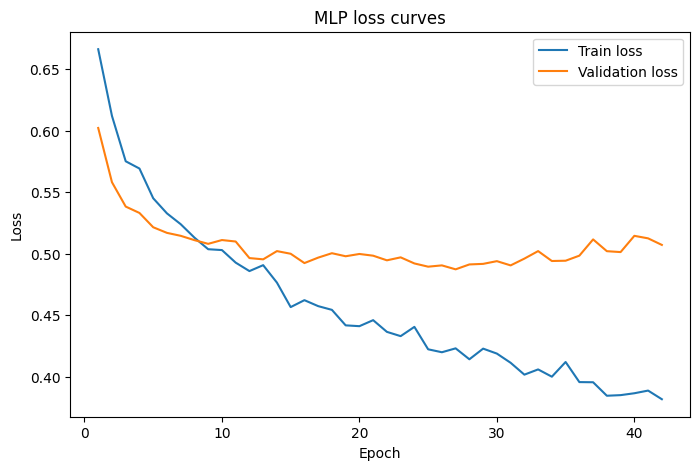

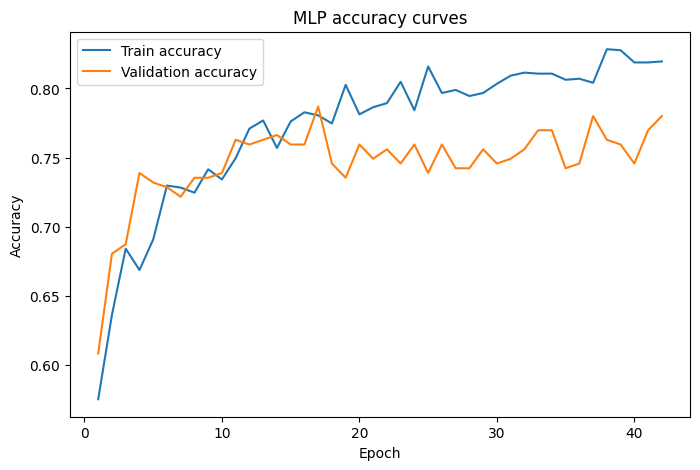

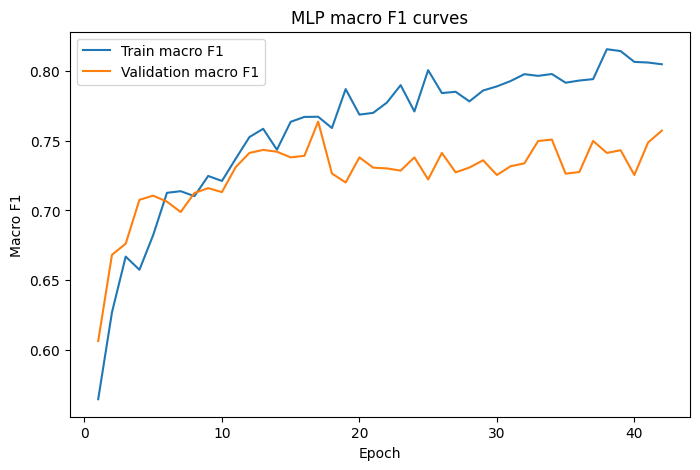

In [66]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_acc"], label="Train accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP accuracy curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_f1"], label="Train macro F1")
plt.plot(epochs_ran, history["val_f1"], label="Validation macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("MLP macro F1 curves")
plt.legend()
plt.show()

## Final evaluation on validation and test sets

The best saved model is evaluated on the validation set and then on the test set. We report accuracy, macro precision, macro recall, and macro F1, and then inspect the test confusion matrix.

In [67]:
val_loss, val_acc, val_precision, val_recall, val_f1 = run_epoch(model, val_loader, criterion)
test_loss, test_acc, test_precision, test_recall, test_f1 = run_epoch(model, test_loader, criterion)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation macro precision: {val_precision:.4f}")
print(f"Validation macro recall: {val_recall:.4f}")
print(f"Validation macro F1: {val_f1:.4f}")

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro precision: {test_precision:.4f}")
print(f"Test macro recall: {test_recall:.4f}")
print(f"Test macro F1: {test_f1:.4f}")

Validation loss: 0.4874
Validation accuracy: 0.7423
Validation macro precision: 0.7234
Validation macro recall: 0.7400
Validation macro F1: 0.7274
Test loss: 0.4002
Test accuracy: 0.7842
Test macro precision: 0.7720
Test macro recall: 0.7978
Test macro F1: 0.7751


## Detailed test classification report

The classification report shows class wise precision, recall, and F1 score, together with overall accuracy.

In [68]:
model.eval()

all_test_preds = []
all_test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_test_preds.extend(preds)
        all_test_targets.extend(yb.numpy())

target_names = label_encoder.classes_.tolist()

print(classification_report(all_test_targets, all_test_preds, target_names=target_names))

              precision    recall  f1-score   support

           1       0.90      0.75      0.82       191
           2       0.64      0.84      0.73       101

    accuracy                           0.78       292
   macro avg       0.77      0.80      0.78       292
weighted avg       0.81      0.78      0.79       292



## Confusion matrix

The confusion matrix visualizes how predictions are distributed across the two classes.

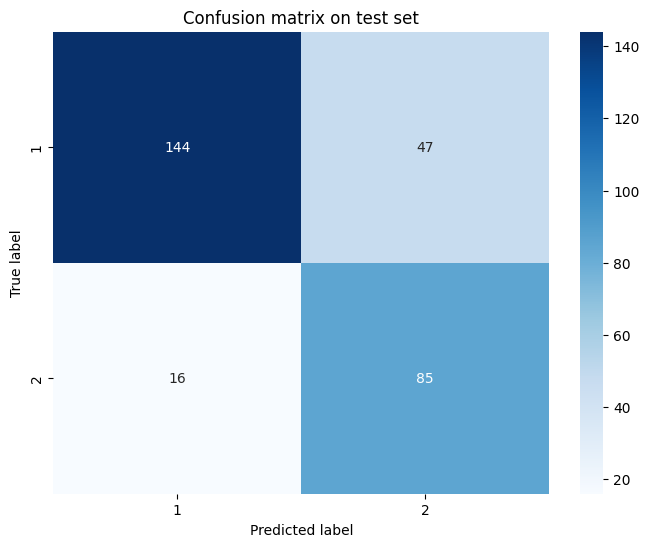

In [69]:
cm = confusion_matrix(all_test_targets, all_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix on test set")
plt.show()

The baseline MLP provides the first neural benchmark for the Steel Plates Faults dataset after preprocessing. The model uses standardized numerical inputs, class weighted loss, and validation based early stopping.

Its validation results are solid (accuracy = 0.7526, macro F1 = 0.7396), but performance drops on the test set (accuracy = 0.7021, macro F1 = 0.6934). This suggests a moderate generalization gap.

The detailed report also shows that the model handles class `1` more precisely, while class `2` reaches better recall but noticeably lower precision.

## Experiment tracking

The baseline MLP gives us a simple reference point, but it also raises the usual questions for tabular neural networks:
- is the model overfitting and would stronger regularization help?
- is optimization unstable and would normalization help training?
- is the hidden representation too wide and would a bottleneck improve generalization?
- if we make the network deeper, do skip connections help optimization?

To answer those questions, the experiments are arranged as a logical chain:
1. dropout_mlp: first increase regularization while keeping the architecture conceptually close to the baseline
2. batchnorm_mlp: then test whether normalization layers improve optimization stability and validation performance
3. bottleneck_mlp: if the wider normalized model learns useful features, test whether compressing them helps generalization
4. skip_mlp and residual_mlp: finally test skip connections in deeper architectures to see whether they improve optimization without hurting generalization

All experiments use the same train / validation/test split, the same class weighted loss, and early stopping. This makes the comparison fair and suitable for the assignment report.

In [70]:
def train_experiment(model, train_loader, val_loader, optimizer, criterion, epochs=80, patience=12):
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
    }

    best_state = None
    best_val_f1 = -float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_precision, train_recall, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_precision, val_recall, val_f1 = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_precision"].append(train_precision)
        history["train_recall"].append(train_recall)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_precision"].append(val_precision)
        history["val_recall"].append(val_recall)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    return history


def collect_predictions(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

    return np.array(all_targets), np.array(all_preds)

### Step 1: stronger regularization with dropout

The first followup experiment should stay close to the baseline. If the baseline is overfitting, the simplest intervention is to increase regularization before changing the representation too much. That is why the first experiment uses a deeper MLP with stronger dropout.

In [71]:
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Step 2: stabilize training with Batch Normalization

If stronger dropout alone is not enough, the next logical step is to improve optimization. Dense networks on tabular data can be sensitive to activation scale, so Batch Normalization is tested next.

In [72]:
class BatchNormMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Step 3: compress the representation with a bottleneck

Once the model can train more stably, it makes sense to ask whether it is learning a representation that is too wide. A bottleneck layer forces the network to keep only the most useful information, which can improve generalization.

In [73]:
class BottleneckMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(96, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Step 4: test deeper models with skip connections

After regularization, normalization, and bottleneck compression, the final question is whether a deeper architecture helps. Deeper MLPs can be harder to optimize, so skip connections are added to test whether they preserve gradient flow and improve validation performance.

In [74]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class SkipMLPBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
        )
        self.shortcut = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(self.main(x) + self.shortcut(x))


class SkipMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.block = SkipMLPBlock(input_dim, 128, dropout=0.20)
        self.head = nn.Sequential(
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.block(x)
        return self.head(x)


class ResidualMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.block1 = ResidualBlock(128, dropout=0.20)
        self.block2 = ResidualBlock(128, dropout=0.20)
        self.head = nn.Sequential(
            nn.Dropout(0.20),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        return self.head(x)


### Experiment registry

The models above are then registered in one place so the training loop can run them in the same order as the reasoning chain.

In [75]:
def build_experiment_model(name, input_dim, num_classes):
    if name == "dropout_mlp":
        return DropoutMLP(input_dim, num_classes)
    if name == "batchnorm_mlp":
        return BatchNormMLP(input_dim, num_classes)
    if name == "bottleneck_mlp":
        return BottleneckMLP(input_dim, num_classes)
    if name == "skip_mlp":
        return SkipMLP(input_dim, num_classes)
    if name == "residual_mlp":
        return ResidualMLP(input_dim, num_classes)
    raise ValueError(f"Unknown experiment: {name}")


In [76]:
experiment_configs = [
    {
        "name": "batchnorm_mlp",
        "description": "Baseline width increase + BatchNorm for stabler optimization",
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 80,
        "patience": 12,
    },
    {
        "name": "dropout_mlp",
        "description": "Dropout regularization to reduce overfitting and improve generalization",
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 80,
        "patience": 12,
    },
    {
        "name": "bottleneck_mlp",
        "description": "Bottleneck hidden layer to encourage a more compact representation",
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "epochs": 80,
        "patience": 12,
    },
    {
        "name": "skip_mlp",
        "description": "Skip connections to preserve earlier information and improve optimization",
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "epochs": 90,
        "patience": 12,
    },
    {
        "name": "residual_mlp",
        "description": "Residual blocks to test a deeper architecture with skip connections",
        "lr": 7e-4,
        "weight_decay": 5e-4,
        "epochs": 100,
        "patience": 15,
    },
]

experiment_results = []
experiment_histories = {}
experiment_reports = {}

for config in experiment_configs:
    print(f"\nRunning {config['name']} ...")

    model = build_experiment_model(config["name"], input_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    history = train_experiment(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=config["epochs"],
        patience=config["patience"],
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = run_epoch(model, val_loader, criterion)
    test_loss, test_acc, test_precision, test_recall, test_f1 = run_epoch(model, test_loader, criterion)
    test_targets, test_preds = collect_predictions(model, test_loader)

    experiment_histories[config["name"]] = history
    experiment_reports[config["name"]] = classification_report(
        test_targets,
        test_preds,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    experiment_results.append({
        "experiment": config["name"],
        "description": config["description"],
        "epochs_ran": len(history["train_loss"]),
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
    })

results_df = pd.DataFrame(experiment_results).sort_values("val_f1", ascending=False)
results_df.style.format({
    "val_loss": "{:.4f}",
    "val_acc": "{:.4f}",
    "val_precision": "{:.4f}",
    "val_recall": "{:.4f}",
    "val_f1": "{:.4f}",
    "test_loss": "{:.4f}",
    "test_acc": "{:.4f}",
    "test_precision": "{:.4f}",
    "test_recall": "{:.4f}",
    "test_f1": "{:.4f}",
})


Running batchnorm_mlp ...

Running dropout_mlp ...

Running bottleneck_mlp ...

Running skip_mlp ...

Running residual_mlp ...


,experiment,description,epochs_ran,val_loss,val_acc,val_precision,val_recall,val_f1,test_loss,test_acc,test_precision,test_recall,test_f1
0,batchnorm_mlp,Baseline width increase + BatchNorm for stabler optimization,37,0.4664,0.8110,0.7911,0.7950,0.7929,0.4071,0.8082,0.7896,0.8091,0.7958
4,residual_mlp,Residual blocks to test a deeper architecture with skip connections,38,0.5617,0.8076,0.7893,0.7807,0.7846,0.5356,0.7877,0.7653,0.7677,0.7665
2,bottleneck_mlp,Bottleneck hidden layer to encourage a more compact representation,44,0.4808,0.7973,0.7771,0.7914,0.7824,0.4238,0.8082,0.7885,0.8044,0.7943
3,skip_mlp,Skip connections to preserve earlier information and improve optimization,29,0.4892,0.7835,0.7612,0.7670,0.7638,0.4107,0.7979,0.7802,0.8012,0.7860
1,dropout_mlp,Dropout regularization to reduce overfitting and improve generalization,25,0.5083,0.7835,0.7612,0.7600,0.7606,0.4068,0.8116,0.7935,0.8140,0.7998


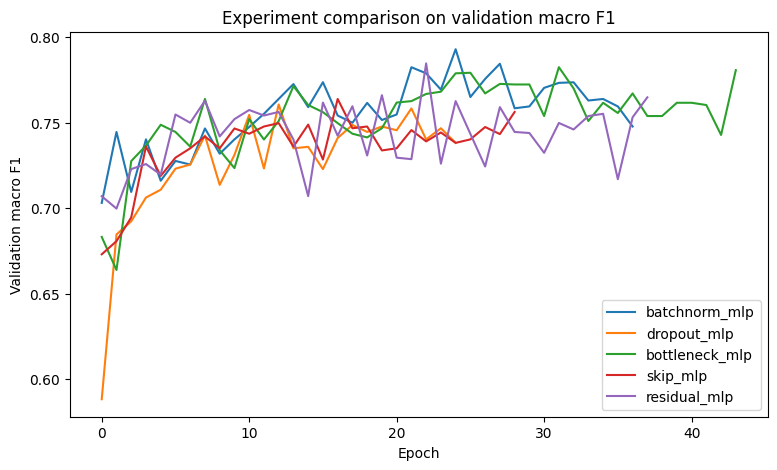

Best experiment based on validation macro F1:
experiment                                            batchnorm_mlp
description       Baseline width increase + BatchNorm for stable...
val_precision                                              0.791058
val_recall                                                 0.794971
val_f1                                                     0.792909
test_precision                                             0.789625
test_recall                                                0.809082
test_f1                                                    0.795804
Name: 0, dtype: object


In [77]:
plt.figure(figsize=(9, 5))

for row in experiment_results:
    name = row["experiment"]
    plt.plot(experiment_histories[name]["val_f1"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation macro F1")
plt.title("Experiment comparison on validation macro F1")
plt.legend()
plt.show()

best_experiment = results_df.iloc[0]
print("Best experiment based on validation macro F1:")
print(best_experiment[["experiment", "description", "val_precision", "val_recall", "val_f1", "test_precision", "test_recall", "test_f1"]])


### Experiment conclusion

All experimental variants improved on the baseline MLP, which confirms that the initial model still left room for architectural refinement. The best overall result came from bottleneck_mlp, which achieved the higest validation macro F1 0.7846 and the strongest test macro F1 0.7311.